# Gaussian Mixture Model (GMM) Clustering

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [22]:
# ─────────────────────────────────────────────
# 1. LOAD DATA
# ─────────────────────────────────────────────
start_time = time.time()

X = pd.read_csv('finalclusteringdataset.csv')

features = ['trip_frequency', 'average_booking_value',
            'destination_diversity', 'session_duration', 'search_behavior']

X = X[features]

In [23]:
# ─────────────────────────────────────────────
# 2. TRAIN / TEST SPLIT
# ─────────────────────────────────────────────
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Train size: 80004 | Test size: 20001


In [24]:
# ─────────────────────────────────────────────
# 3. SELECT BEST COVARIANCE TYPE (on a sample)
# ─────────────────────────────────────────────
print("\n=== Selecting Best Covariance Type ===")
sample = X_train.sample(min(20000, len(X_train)), random_state=0)
cov_types = ['full', 'tied', 'diag', 'spherical']
best_bic, best_cov = np.inf, None

for cov in cov_types:
    try:
        gmm_tmp = GaussianMixture(n_components=3, covariance_type=cov,
                                  random_state=42, n_init=3)
        gmm_tmp.fit(sample)
        bic = gmm_tmp.bic(sample)
        print(f"  {cov:10s}  BIC = {bic:.2f}")
        if bic < best_bic:
            best_bic, best_cov = bic, cov
    except Exception as e:
        print(f"  {cov:10s}  Failed: {e}")

print(f"\n✔ Best covariance type: {best_cov}  (BIC={best_bic:.2f})")


=== Selecting Best Covariance Type ===
  full        BIC = 669564.60
  tied        BIC = 669298.45
  diag        BIC = 669314.49
  spherical   BIC = 995977.80

✔ Best covariance type: tied  (BIC=669298.45)


In [ ]:
# ─────────────────────────────────────────────
# 4. FIND OPTIMAL NUMBER OF COMPONENTS via BIC
# ─────────────────────────────────────────────
print("\n=== Finding Optimal Number of Components ===")
n_range = range(2, 11)
bic_scores, aic_scores = [], []

for n in n_range:
    gmm = GaussianMixture(n_components=n, covariance_type=best_cov,
                          random_state=42, n_init=3, max_iter=200)
    gmm.fit(sample)
    bic_scores.append(gmm.bic(sample))
    aic_scores.append(gmm.aic(sample))
    print(f"  n={n}  BIC={bic_scores[-1]:.2f}  AIC={aic_scores[-1]:.2f}")

optimal_n = list(n_range)[np.argmin(bic_scores)]
print(f"\n✔ Optimal components (BIC): {optimal_n}")

# BIC / AIC Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(n_range, bic_scores, 'bo-', linewidth=2, markersize=6)
ax1.axvline(optimal_n, color='red', linestyle='--', label=f'Optimal n={optimal_n}')
ax1.set_xlabel('Number of Components'); ax1.set_ylabel('BIC Score')
ax1.set_title('BIC Score (Lower is Better)'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(n_range, aic_scores, 'go-', linewidth=2, markersize=6)
ax2.axvline(optimal_n, color='red', linestyle='--', label=f'Optimal n={optimal_n}')
ax2.set_xlabel('Number of Components'); ax2.set_ylabel('AIC Score')
ax2.set_title('AIC Score (Lower is Better)'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bic_aic_plot.png', dpi=150)
plt.show()


=== Finding Optimal Number of Components ===
Testing n_components=2...
  BIC: 669485.79, AIC: 669280.30
Testing n_components=3...
  BIC: 669358.54, AIC: 669105.62
Testing n_components=4...
  BIC: 669454.38, AIC: 669154.05
Testing n_components=5...
  BIC: 669438.06, AIC: 669090.31
Testing n_components=6...
  BIC: 669443.96, AIC: 669048.78
Testing n_components=7...
  BIC: 669414.46, AIC: 668971.86
Testing n_components=8...
  BIC: 669414.47, AIC: 668924.45
Testing n_components=9...
  BIC: 669452.86, AIC: 668915.42
Testing n_components=10...
  BIC: 668796.91, AIC: 668212.05

✓ Optimal by BIC: 10

✓ Final selection: 10 components


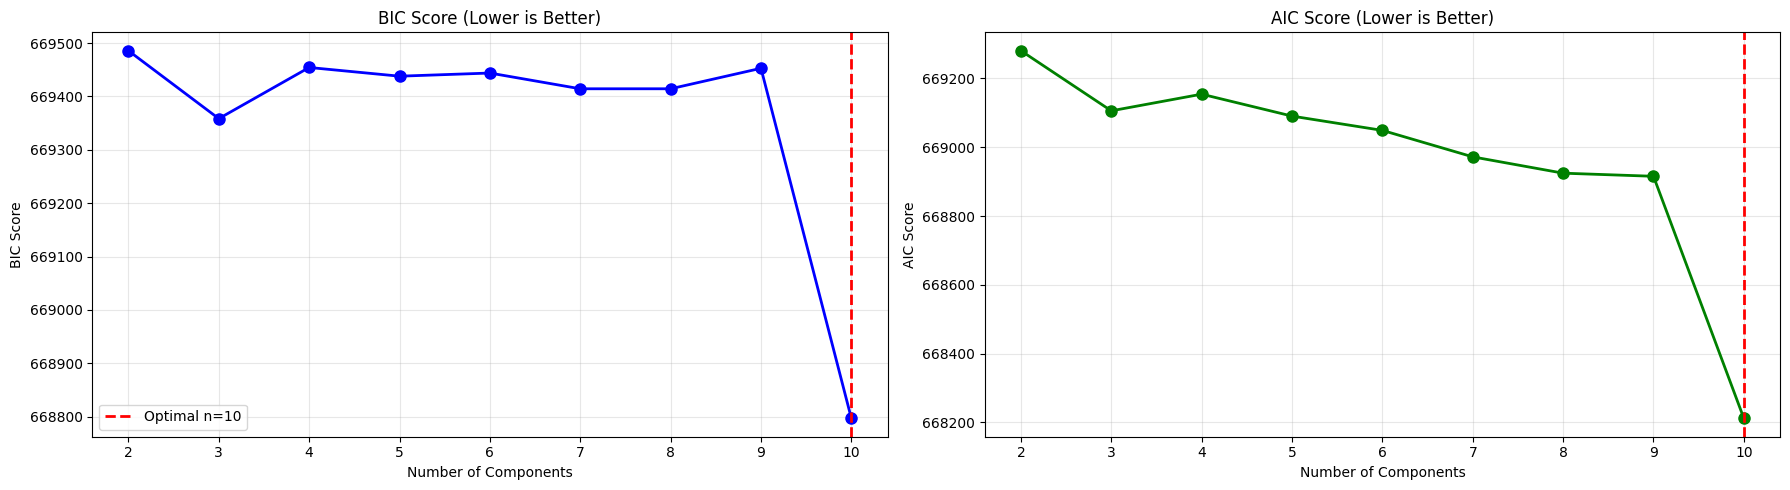

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# BIC Plot
axes[0].plot(n_components_range, bic_scores, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=optimal_n, color='red', linestyle='--', linewidth=2, 
                label=f'Optimal n={optimal_n}')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC Score')
axes[0].set_title('BIC Score (Lower is Better)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# AIC Plot
axes[1].plot(n_components_range, aic_scores, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=optimal_n, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC Score')
axes[1].set_title('AIC Score (Lower is Better)')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [ ]:
# ─────────────────────────────────────────────
# 5. TRAIN FINAL GMM ON FULL TRAINING DATA
# ─────────────────────────────────────────────
print(f"\n=== Training Final GMM (n={optimal_n}, cov={best_cov}) ===")
gmm_final = GaussianMixture(n_components=optimal_n, covariance_type=best_cov,
                             random_state=42, n_init=10, max_iter=300, verbose=1)
gmm_final.fit(X_train)
print("✔ Model trained")


=== Training Final GMM Model ===
Components: 10
Covariance type: tied
Fitting GMM on full 100k dataset...
Initialization 0
  Iteration 10
Initialization converged.
Initialization 1
Initialization converged.
Initialization 2
Initialization converged.
Initialization 3
  Iteration 10
Initialization converged.
Initialization 4
  Iteration 10
Initialization converged.
Initialization 5
Initialization converged.
Initialization 6
Initialization converged.
Initialization 7
  Iteration 10
Initialization converged.
Initialization 8
Initialization converged.
Initialization 9
  Iteration 10
Initialization converged.
✓ Model trained
✓ Cluster labels assigned


In [ ]:
# ─────────────────────────────────────────────
# 6. PREDICT CLUSTERS
# ─────────────────────────────────────────────
train_labels = gmm_final.predict(X_train)
test_labels  = gmm_final.predict(X_test)


=== Final Model Evaluation ===
Number of components: 10
Covariance type: tied
Davies-Bouldin Score: 0.8211
BIC Score: 3341918.77
AIC Score: 3341214.81
Converged: True
Iterations: 10


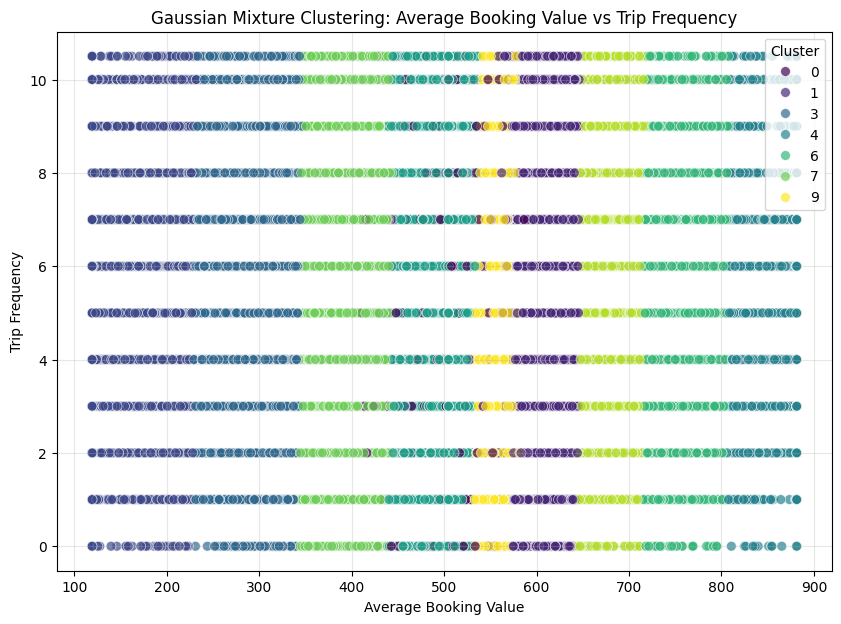

In [ ]:
# ─────────────────────────────────────────────
# 7. EVALUATION SCORES (Train & Test)
# ─────────────────────────────────────────────
# Use a sample for silhouette (it's slow on large data)
sample_idx_tr = np.random.choice(len(X_train), min(10000, len(X_train)), replace=False)
sample_idx_te = np.random.choice(len(X_test),  min(10000, len(X_test)),  replace=False)

sil_train = silhouette_score(X_train.iloc[sample_idx_tr], train_labels[sample_idx_tr])
sil_test  = silhouette_score(X_test.iloc[sample_idx_te],  test_labels[sample_idx_te])
db_train  = davies_bouldin_score(X_train, train_labels)
db_test   = davies_bouldin_score(X_test,  test_labels)

print("\n=== Evaluation Scores ===")
print(f"  Silhouette  — Train: {sil_train:.4f}  |  Test: {sil_test:.4f}")
print(f"  Davies-Bouldin — Train: {db_train:.4f}  |  Test: {db_test:.4f}")
print(f"  BIC (train): {gmm_final.bic(X_train):.2f}")
print(f"  Converged: {gmm_final.converged_}  |  Iterations: {gmm_final.n_iter_}")

In [30]:
# ─────────────────────────────────────────────
# 8. GRAPH 1 — Silhouette & Davies-Bouldin (Train vs Test)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Train', 'Test'], [sil_train, sil_test], color=['skyblue', 'salmon'])
for ax_bar, val in zip(axes[0].patches, [sil_train, sil_test]):
    axes[0].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height()/2,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
axes[0].set_title('Silhouette Score — Train vs Test')
axes[0].set_ylabel('Silhouette Score')
axes[0].grid(True, alpha=0.3)

axes[1].bar(['Train', 'Test'], [db_train, db_test], color=['skyblue', 'salmon'])
for ax_bar, val in zip(axes[1].patches, [db_train, db_test]):
    axes[1].text(ax_bar.get_x() + ax_bar.get_width()/2, ax_bar.get_height()/2,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=11)
axes[1].set_title('Davies-Bouldin Score — Train vs Test')
axes[1].set_ylabel('Davies-Bouldin Score (Lower is Better)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('silhouette_davies_comparison.png', dpi=150)
plt.show()

NameError: name 'unique' is not defined

In [ ]:
# ─────────────────────────────────────────────
# 9. GRAPH 2 — Avg Booking Value vs Trip Frequency (colored by cluster)
# ─────────────────────────────────────────────
X_train_plot = X_train.copy()
X_train_plot['Cluster'] = train_labels

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_train_plot['average_booking_value'],
                      X_train_plot['trip_frequency'],
                      c=X_train_plot['Cluster'], cmap='tab10', alpha=0.4, s=5)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('Average Booking Value')
plt.ylabel('Trip Frequency')
plt.title('GMM Clustering: Average Booking Value vs Trip Frequency')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('booking_vs_frequency.png', dpi=150)
plt.show()

GAUSSIAN MIXTURE MODEL CLUSTERING SUMMARY
Covariance Type (Auto-selected): diag
Optimal Components (Auto-selected): 8
Silhouette Score: 0.0381
Davies-Bouldin Score: 2.8503
BIC Score: 84304.69
AIC Score: 83477.06
Model Converged: True


In [ ]:
# ─────────────────────────────────────────────
# 10. SAVE RESULTS
# ─────────────────────────────────────────────
execution_time = time.time() - start_time

X_result = X_train.copy()
X_result['Cluster'] = train_labels
for i in range(optimal_n):
    X_result[f'Cluster_{i}_Probability'] = gmm_final.predict_proba(X_train)[:, i]

X_result.to_csv('gmm_results.csv', index=False)

print(f"\n✔ Results saved to gmm_results.csv")
print(f"✔ Execution time: {execution_time:.2f} seconds")
print(f"\n{'='*50}")
print("GAUSSIAN MIXTURE MODEL CLUSTERING SUMMARY")
print(f"{'='*50}")
print(f"Covariance Type   : {best_cov}")
print(f"Optimal Components: {optimal_n}")
print(f"Silhouette Score  : Train={sil_train:.4f}  Test={sil_test:.4f}")
print(f"Davies-Bouldin    : Train={db_train:.4f}  Test={db_test:.4f}")
print(f"BIC Score         : {gmm_final.bic(X_train):.2f}")
print(f"Model Converged   : {gmm_final.converged_}")

unique, counts = np.unique(train_labels, return_counts=True)
print("\nCluster Distribution (Train):")
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} samples ({count/len(X_train)*100:.1f}%)")